### **CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS**

Nesta célula, importamos todas as bibliotecas necessárias para a análise e construção dos modelos de Machine Learning. Cada biblioteca tem uma função específica:

*   **`pandas` (pd)**: Utilizada para manipulação e análise de dados, especialmente DataFrames.
*   **`numpy` (np)**: Fundamental para operações numéricas e matemáticas de alto desempenho.
*   **`matplotlib.pyplot` (plt)** e **`seaborn` (sns)**: Usadas para visualização de dados e criação de gráficos estatísticos.
*   **`sklearn.model_selection.train_test_split`**: Para dividir os dados em conjuntos de treinamento e teste.
*   **`sklearn.preprocessing.LabelEncoder`**: Para transformar variáveis categóricas em numéricas.
*   **`sklearn.ensemble.RandomForestClassifier`** e **`sklearn.naive_bayes.GaussianNB`**: Os algoritmos de Machine Learning que serão treinados.
*   **`sklearn.metrics`**: Contém funções para avaliar o desempenho dos modelos, como acurácia, precisão, recall, F1-Score e matriz de confusão.

O `sns.set(style="whitegrid")` configura um estilo padrão para os gráficos, tornando-os mais legíveis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.linear_model import Perceptron
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

sns.set(style="whitegrid")
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
!pip install -q lightgbm torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00


In [ ]:
import lightgbm as lgb
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv
print("Bibliotecas adicionais (LGBM e GNN) instaladas e importadas!")

Bibliotecas adicionais (LGBM e GNN) instaladas e importadas!


### **CÉLULA 2: CARREGAMENTO E VISUALIZAÇÃO DOS DADOS**

Esta célula é responsável por carregar o conjunto de dados (`baseMLJurandir.csv`) em um DataFrame do pandas. Após o carregamento, exibimos as primeiras 5 linhas (`df.head()`) para ter uma visão inicial dos dados e confirmamos suas dimensões (`df.shape`).

Um bloco `try-except` é usado para lidar com a situação em que o arquivo não é encontrado, fornecendo uma mensagem de erro útil para o usuário.

In [ ]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO E VISUALIZAÇÃO DOS DADOS
# ==============================================================================
try:
    df = pd.read_csv('baseMLJurandir.csv')
    print(f"Dataset carregado com sucesso! Dimensões: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("ERRO: O arquivo 'baseMLJurandir.csv' não foi encontrado.")
    print("Por favor, faça o upload do arquivo na aba de arquivos à esquerda ou verifique o caminho.")

Dataset carregado com sucesso! Dimensões: (1084215, 12)


,saltos,nÃºcleo,modulaÃ§Ã£o,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,consumo energia,peso,resultado
0,1,5,16.0,1050.0,1,3,-120.0,16.613496,2.000000e+11,0.0,0.0,1
1,3,5,4.0,2850.0,1,3,-120.0,12.349501,1.000000e+11,0.0,0.0,1
2,3,5,4.0,2850.0,1,10,-120.0,12.227845,4.000000e+11,0.0,0.0,1
3,3,5,4.0,2850.0,1,8,-120.0,12.253261,3.000000e+11,0.0,0.0,1
4,3,5,8.0,1550.0,1,9,-120.0,14.713263,5.000000e+11,0.0,0.0,1


## **CÉLULA 3: PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES**

Esta etapa é crucial para preparar os dados antes do treinamento dos modelos. Nesta versão, o processamento foi adaptado para suportar uma **classificação binária**, simplificando o problema para distinguir apenas entre circuitos aceitos e circuitos bloqueados.

### Correção de Colunas com Erro de Encoding
Foram identificados e corrigidos nomes de colunas com caracteres corrompidos (por exemplo: `Ãºcleo` → `núcleo`, além de variações relacionadas à modulação). Essa padronização garante que o código consiga manipular corretamente todas as variáveis do conjunto de dados.

### Definição da Variável Target (`resultado`)
Os diferentes tipos de bloqueio foram **agrupados em uma única classe**, transformando o problema em binário. A variável `resultado` passou a representar apenas a aceitação ou bloqueio do circuito, conforme:

- **0 → Bloqueio (qualquer motivo)**  
- **1 → Aceito**

Essa simplificação permite que o modelo foque exclusivamente em prever se uma requisição será atendida ou não, sem diferenciar a causa específica do bloqueio, tornando o problema mais direto e reduzindo a complexidade da classificação.

### Engenharia de Features (`slots_usados`)
Foi criada uma nova feature chamada **`slots_usados`**, calculada como:

`slots_usados = ultimo_slot - primeiro_slot`

Essa variável representa a largura espectral utilizada pela requisição. As colunas originais **`primeiro_slot`** e **`ultimo_slot`** foram mantidas, pois a posição do espectro também pode conter informações relevantes para o modelo.

### Remoção de Colunas Específicas
Foram removidas as colunas relacionadas a peso e consumo de energia. A exclusão considerou possíveis variações nos nomes das colunas, garantindo a limpeza completa, já que essas variáveis não serão utilizadas na predição.

### Codificação da Modulação
A variável categórica **`modulação`** foi convertida para valores numéricos utilizando **LabelEncoder**, permitindo que os algoritmos de Machine Learning processem corretamente essa informação textual.

### Validação Final
Ao final do pré-processamento, a estrutura do **DataFrame** é exibida para confirmar que:

- a coluna **`resultado`** está no formato binário (0 e 1)  
- as colunas de peso e consumo foram removidas  
- as novas features foram criadas corretamente  
- os dados estão prontos para o treinamento dos modelos


Colunas do DataFrame antes do pré-processamento: ['saltos', 'nÃºcleo', 'modulaÃ§Ã£o', 'comprimento', 'primeiro slot', 'ultimo slot', 'XT', 'OSNR', 'banda', 'consumo energia', 'peso', 'resultado']
Coluna 'nÃºcleo' renomeada para 'núcleo'.
Coluna 'modulaÃ§Ã£o' renomeada para 'modulação'.
Variável 'resultado' transformada para BINÁRIA: 1=Aceito, 0=Bloqueado (QoT/XT).
Distribuição das classes em 'resultado':
resultado
0    374983
1    709232
Name: count, dtype: int64


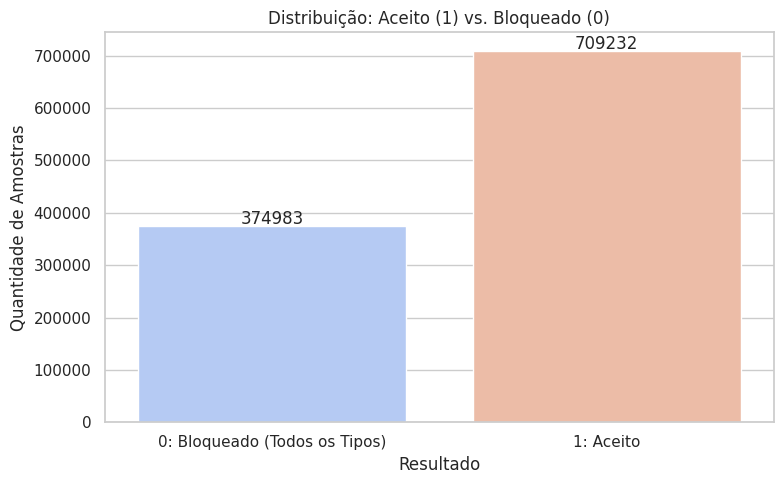

Sucesso! Colunas removidas: ['consumo energia', 'peso']

--- Estrutura Final do Dataset ---


,saltos,núcleo,modulação,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,resultado,slots_usados
0,1,5,16.0,1050.0,1,3,-120.0,16.613496,2.000000e+11,1,3
1,3,5,4.0,2850.0,1,3,-120.0,12.349501,1.000000e+11,1,3
2,3,5,4.0,2850.0,1,10,-120.0,12.227845,4.000000e+11,1,10
3,3,5,4.0,2850.0,1,8,-120.0,12.253261,3.000000e+11,1,8
4,3,5,8.0,1550.0,1,9,-120.0,14.713263,5.000000e+11,1,9


Colunas finais: ['saltos', 'núcleo', 'modulação', 'comprimento', 'primeiro slot', 'ultimo slot', 'XT', 'OSNR', 'banda', 'resultado', 'slots_usados']


In [ ]:
# ==============================================================================
# CÉLULA 3: PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Colunas do DataFrame antes do pré-processamento:", df.columns.tolist())

def corrigir_coluna(df, prefixo_esperado, sufixos_erro, nome_correto):
    found_col = None
    for col in df.columns:
        if prefixo_esperado in col.lower():
            for sufixo in sufixos_erro:
                if sufixo in col:
                    found_col = col
                    break
            if found_col:
                break

    if found_col and found_col != nome_correto:
        df.rename(columns={found_col: nome_correto}, inplace=True)
        print(f"Coluna '{found_col}' renomeada para '{nome_correto}'.")
    elif found_col and found_col == nome_correto:
        print(f"Coluna '{nome_correto}' já está com o nome correto.")

corrigir_coluna(df, 'n', ['Ãºcleo'], 'núcleo')
corrigir_coluna(df, 'modula', ['Ã§Ã£o', 'ção'], 'modulação')

# 2. Tratamento da Variável Target (TRANSFORMAÇÃO BINÁRIA)
# Regra: Se for 1 (Aceito) mantem 1. Todo o resto (2,3,4,5) vira 0.
df['resultado'] = df['resultado'].apply(lambda x: 1 if x == 1 else 0)

print("Variável 'resultado' transformada para BINÁRIA: 1=Aceito, 0=Bloqueado (QoT/XT).")

# Imprimir contagem textual
print("Distribuição das classes em 'resultado':")
contagem = df['resultado'].value_counts().sort_index()
print(contagem)

plt.figure(figsize=(8, 5))

# Correção do aviso do Seaborn: Adicionado hue='resultado' e legend=False
ax = sns.countplot(x='resultado', data=df, hue='resultado', palette='coolwarm', legend=False)

plt.title('Distribuição: Aceito (1) vs. Bloqueado (0)')
plt.xlabel('Resultado')
plt.ylabel('Quantidade de Amostras')

# Legenda explicativa atualizada para Binário
labels_map = {
    1: '1: Aceito',
    0: '0: Bloqueado (Todos os Tipos)'
}

# Ajusta os labels do eixo X
classes_presentes = sorted(df['resultado'].unique())
labels_finais = [labels_map.get(c, str(c)) for c in classes_presentes]

ax.set_xticks(range(len(classes_presentes)))
ax.set_xticklabels(labels_finais)

# Adicionar números em cima das barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Criar feature "slots_usados"
df['slots_usados'] = df['ultimo slot'] - df['primeiro slot'] + 1

colunas_para_remover = []
for col in df.columns:
    c_lower = col.strip().lower()
    if c_lower == 'peso' or ('consumo' in c_lower and 'energia' in c_lower):
        colunas_para_remover.append(col)

if colunas_para_remover:
    df.drop(colunas_para_remover, axis=1, inplace=True)
    print(f"Sucesso! Colunas removidas: {colunas_para_remover}")
else:
    print("AVISO: Não encontrei as colunas 'peso' ou 'consumo de energia'.")

# 4. LabelEncoder para modulação
le = LabelEncoder()
if 'modulação' in df.columns and df['modulação'].dtype == 'object':
    df['modulação'] = le.fit_transform(df['modulação'])
    print("Classes de modulação codificadas:", list(le.classes_))

print("\n--- Estrutura Final do Dataset ---")
display(df.head())
print(f"Colunas finais: {df.columns.tolist()}")

### **CÉLULA 3.1: ENGENHARIA DE FEATURES AVANÇADA E SELEÇÃO**

Para melhorar o poder de generalização, vamos criar métricas que relacionam a topologia com a qualidade física:
* **Distância por Salto**: Indica a média de comprimento de cada trecho.
* **Interação OSNR-Comprimento**: Captura a degradação não linear do sinal.
* **Escalonamento Robusto**: Utiliza o `RobustScaler` para que outliers no OSNR ou XT não prejudiquem o aprendizado.

In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Aplicando as transformações no DataFrame principal
if 'df' in globals():
    # 1. Criação de Novas Features de Engenharia de Tráfego
    df['dist_por_salto'] = df['comprimento'] / (df['saltos'] + 1)
    df['interacao_osnr_dist'] = df['OSNR'] * df['comprimento']
    df['densidade_espectral'] = df['slots_usados'] / (df['comprimento'] + 1)

    # 2. Escalonamento Robusto
    scaler = RobustScaler()
    features_to_scale = ['saltos', 'comprimento', 'XT', 'OSNR', 'dist_por_salto', 'interacao_osnr_dist', 'densidade_espectral']
    df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

    print("Novas features criadas e dados escalonados.")
    display(df.head())
else:
    print("Erro: Execute as células de carregamento de dados (Célula 2 e 3) antes desta.")

Novas features criadas e dados escalonados.


,saltos,núcleo,modulação,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,resultado,slots_usados,dist_por_salto,interacao_osnr_dist,densidade_espectral
0,-1.0,5,16.0,-0.517241,1,3,-0.941087,0.727718,2.000000e+11,1,3,0.000000,-0.566700,0.184352
1,1.0,5,4.0,0.724138,1,3,-0.941087,-0.511181,1.000000e+11,1,3,0.681818,0.654810,-0.744851
2,1.0,5,4.0,0.724138,1,10,-0.941087,-0.546528,4.000000e+11,1,10,0.681818,0.630953,0.521102
3,1.0,5,4.0,0.724138,1,8,-0.941087,-0.539143,3.000000e+11,1,8,0.681818,0.635937,0.159401
4,1.0,5,8.0,-0.172414,1,9,-0.941087,0.175607,5.000000e+11,1,9,-0.500000,-0.197783,1.704501


## CÉLULA A: MATRIZ DE CORRELAÇÃO

Nesta etapa realizamos a análise de correlação entre as variáveis numéricas do conjunto de dados com o objetivo de identificar relações lineares, dependências fortes e possíveis problemas de multicolinearidade que possam impactar o desempenho dos modelos de Machine Learning. Inicialmente, é criada uma figura com tamanho ampliado para melhorar a visualização. Em seguida, a matriz de correlação é calculada utilizando `df.corr()`, que considera apenas colunas numéricas automaticamente. Posteriormente, essa matriz é representada visualmente por meio de um heatmap gerado com Seaborn, no qual cada célula exibe o valor da correlação entre duas variáveis, variando de -1 a 1. Valores próximos de 1 indicam forte correlação positiva, próximos de -1 indicam forte correlação negativa e próximos de 0 indicam pouca ou nenhuma relação linear. A anotação dos valores (`annot=True`) facilita a interpretação direta, enquanto o mapa de cores `coolwarm` destaca visualmente as intensidades das correlações. Essa análise auxilia na identificação de variáveis redundantes, possíveis features altamente relacionadas e oportunidades de seleção ou redução de dimensionalidade antes do treinamento dos modelos.


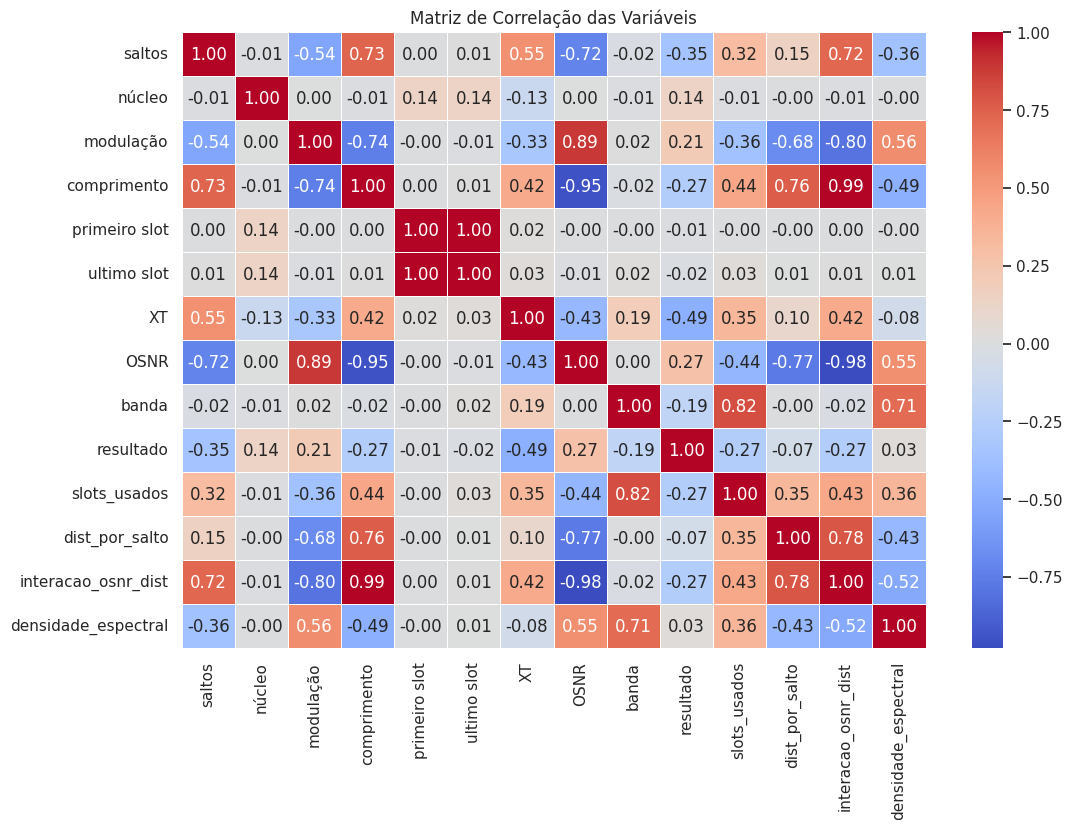

In [ ]:
# ==============================================================================
# NOVA CÉLULA A: MATRIZ DE CORRELAÇÃO
# ==============================================================================

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

### **CÉLULA 4: SEPARAÇÃO EM TREINO E TESTE**

Para avaliar corretamente o desempenho de um modelo de Machine Learning, é fundamental dividirmos o conjunto de dados em duas partes:

*   **Conjunto de Treino (Training Set)**: Usado para treinar o modelo, ou seja, para que ele aprenda os padrões nos dados.
*   **Conjunto de Teste (Test Set)**: Usado para avaliar o desempenho do modelo em dados *nunca antes vistos*. Isso nos ajuda a ter uma ideia de como o modelo se comportará em situações reais e a evitar o *overfitting* (quando o modelo memoriza os dados de treino, mas não generaliza bem para novos dados).

Aqui, utilizamos `train_test_split` para separar os dados em 70% para treino e 30% para teste. O parâmetro `random_state=42` garante que a divisão seja sempre a mesma cada vez que o código for executado, tornando os resultados reprodutíveis.

In [ ]:
# ==============================================================================
# CÉLULA 4: SEPARAÇÃO EM TREINO E TESTE
# ==============================================================================

X = df.drop('resultado', axis=1)
y = df['resultado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Novas features incluídas: {X.columns.tolist()}")
print(f"Tamanho do Treino: {X_train.shape[0]} | Tamanho do Teste: {X_test.shape[0]}")

Novas features incluídas: ['saltos', 'núcleo', 'modulação', 'comprimento', 'primeiro slot', 'ultimo slot', 'XT', 'OSNR', 'banda', 'slots_usados', 'dist_por_salto', 'interacao_osnr_dist', 'densidade_espectral']
Tamanho do Treino: 758950 | Tamanho do Teste: 325265


=== DISTRIBUIÇÃO ORIGINAL ===
resultado
0    262488
1    496462
Name: count, dtype: int64

Classe 0: 262488
Classe 1: 496462

=== DISTRIBUIÇÃO BALANCEADA ===
resultado
0    262488
1    262488
Name: count, dtype: int64
Tamanho final do treino: 524976


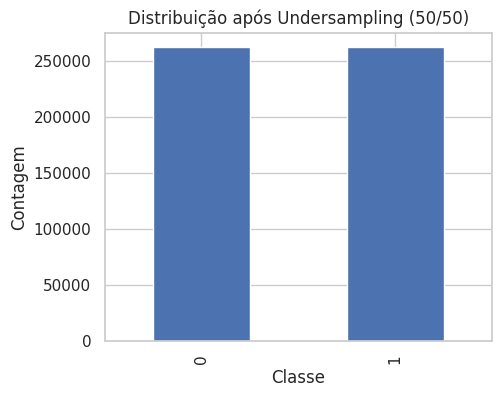

In [ ]:
# ==============================================================================
# CÉLULA 4.1: BALANCEAMENTO DO CONJUNTO DE TREINO
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

print("=== DISTRIBUIÇÃO ORIGINAL ===")
print(y_train.value_counts().sort_index())

# 1) Reconstruir dataframe temporário com X + y
df_train = pd.concat([X_train, y_train], axis=1)

# 2) Separar classes
df_minority = df_train[df_train['resultado'] == 0]
df_majority = df_train[df_train['resultado'] == 1]

print(f"\nClasse 0: {len(df_minority)}")
print(f"Classe 1: {len(df_majority)}")

# 3) Undersampling da majoritária
df_majority_down = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# 4) Combinar e embaralhar
df_balanced = pd.concat([df_minority, df_majority_down]).sample(
    frac=1,
    random_state=42
)

# 5) Separar novamente X e y
X_train_bal = df_balanced.drop(columns='resultado')
y_train_bal = df_balanced['resultado']

print("\n=== DISTRIBUIÇÃO BALANCEADA ===")
print(y_train_bal.value_counts().sort_index())
print(f"Tamanho final do treino: {len(X_train_bal)}")

# 6) Visualização simples
plt.figure(figsize=(5,4))
y_train_bal.value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição após Undersampling (50/50)")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()


### **CÉLULA 5: TREINAMENTO DOS MODELOS**

Nesta célula, inicializamos e treinamos dois modelos de classificação diferentes:

1.  **Random Forest Classifier**: É um algoritmo de *ensemble learning* que constrói múltiplas árvores de decisão durante o treinamento e produz a classe que é a moda das classes de árvores individuais. É robusto, lida bem com dados não lineares e é menos propenso a overfitting que uma única árvore de decisão. O `n_estimators=200` indica que 100 árvores serão construídas.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ==============================================================================
# CÉLULA 5: TREINAMENTO - RANDOM FOREST
# ==============================================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bal, y_train_bal)
print("Modelo Random Forest Otimizado treinado com sucesso!")

Modelo Random Forest Otimizado treinado com sucesso!


### **CÉLULA 5.1: TREINAMENTO DO MODELO XGBOOST**

O **XGBoost (Extreme Gradient Boosting)** é um algoritmo de *gradient boosting* que se destaca pela sua performance e eficiência. Ele constrói uma sequência de árvores de decisão, onde cada nova árvore tenta corrigir os erros das árvores anteriores. É altamente configurável e possui otimizações para lidar com grandes volumes de dados, o que o torna uma escolha popular em competições de Machine Learning.

Nesta célula, inicializamos e treinamos o `XGBClassifier`. Os parâmetros `use_label_encoder=False` e `eval_metric='logloss'` são configurações recomendadas para lidar com avisos de depreciação e para uma avaliação adequada em problemas de classificação binária, respectivamente.

In [ ]:
from xgboost import XGBClassifier

# ==============================================================================
# CÉLULA 5.1: TREINAMENTO - XGBOOST
# ==============================================================================

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.7,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_bal, y_train_bal)
print("Modelo XGBoost com Regularização treinado com sucesso!")

Modelo XGBoost com Regularização treinado com sucesso!


### **CÉLULA 5.2: TREINAMENTO DO LIGHTGBM**

O LightGBM é um framework de gradient boosting que utiliza algoritmos baseados em árvores, otimizado para velocidade e eficiência de memória.

In [ ]:
# 7. LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train_bal, y_train_bal)
print("Modelo LightGBM treinado.")

Modelo LightGBM treinado.


### **CÉLULA 5.3: TREINAMENTO DO NAIVE BAYES E GCN**

Nesta etapa, aplicamos o `PowerTransformer` (Yeo-Johnson) para estabilizar a variância e tornar os dados mais Gaussianos, o que beneficia diretamente o Naive Bayes. Além disso, expandimos a arquitetura da GCN com mais neurônios e um ciclo de 100 épocas.

In [ ]:
from sklearn.preprocessing import PowerTransformer
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

pt = PowerTransformer(method='yeo-johnson')
X_train_pt = pt.fit_transform(X_train_bal)
X_test_pt = pt.transform(X_test)

nb_model_opt = GaussianNB()
nb_model_opt.fit(X_train_pt, y_train_bal)
print("Naive Bayes re-treinado com PowerTransformer.")

# 2. GCN
class EON_GCN_Deep(torch.nn.Module):
    def __init__(self, num_features):
        super(EON_GCN_Deep, self).__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.bn1 = torch.nn.BatchNorm1d(64)
        self.conv2 = GCNConv(64, 32)
        self.bn2 = torch.nn.BatchNorm1d(32)
        self.conv3 = GCNConv(32, 16)
        self.fc = torch.nn.Linear(16, 2)

    def forward(self, x, edge_index):
        x = F.leaky_relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.leaky_relu(self.bn2(self.conv2(x, edge_index)))
        x = F.leaky_relu(self.conv3(x, edge_index))
        return F.log_softmax(self.fc(x), dim=1)

X_train_t_opt = torch.tensor(X_train_pt, dtype=torch.float)
y_train_t = torch.tensor(y_train_bal.values, dtype=torch.long)

edge_index = torch.tensor([[i for i in range(len(X_train_t_opt))],
                           [i for i in range(len(X_train_t_opt))]], dtype=torch.long)

gnn_opt_model = EON_GCN_Deep(X_train_t_opt.shape[1])
optimizer_opt = torch.optim.AdamW(gnn_opt_model.parameters(), lr=0.001, weight_decay=1e-3)

gnn_opt_model.train()
print("Iniciando treinamento da GNN...")
for epoch in range(100):
    optimizer_opt.zero_grad()
    out = gnn_opt_model(X_train_t_opt, edge_index)
    loss = F.nll_loss(out, y_train_t)
    loss.backward()
    optimizer_opt.step()
    if (epoch+1) % 20 == 0:
        print(f"Época {epoch+1}/100 - Erro: {loss.item():.4f}")

print("Otimizações concluídas!")

Naive Bayes re-treinado com PowerTransformer.
Iniciando treinamento da GNN...
Época 20/100 - Erro: 0.5819
Época 40/100 - Erro: 0.4987
Época 60/100 - Erro: 0.4624
Época 80/100 - Erro: 0.4456
Época 100/100 - Erro: 0.4348
Otimizações concluídas!


### **CÉLULA 6: AVALIAÇÃO DOS MODELOS**

Após treinar os modelos, é fundamental avaliar seu desempenho. Uma função auxiliar `avaliar_modelo` foi criada para calcular e exibir métricas de avaliação comuns e uma matriz de confusão para cada modelo.

#### **Métricas de Avaliação:**

*   **Acurácia (Accuracy)**: A proporção de previsões corretas em relação ao total de previsões. É útil quando as classes são balanceadas.

*   **Precisão (Precision)**: Das previsões positivas do modelo, quantas estavam realmente corretas? É crucial quando o custo de um falso positivo é alto. Por exemplo, se nosso modelo prevê que um circuito será aceito (positivo), a precisão nos diz a chance de que ele *realmente* seja aceito.

*   **Recall (Sensibilidade)**: Dos casos realmente positivos, quantos o modelo conseguiu identificar corretamente? É fundamental quando o custo de um falso negativo é alto. Por exemplo, se um circuito *deveria* ser aceito (positivo real), o recall nos diz a chance de o modelo prevê-lo como aceito. No nosso contexto de aceitação/bloqueio de circuitos, um **alto Recall** para a classe `aceito=1` significa que o modelo é bom em identificar a maioria dos circuitos que *devem* ser aceitos, minimizando a chance de bloquear erroneamente um circuito válido (Falso Negativo).

*   **F1-Score**: É a média harmônica da Precisão e do Recall. É uma métrica útil quando se busca um equilíbrio entre Precisão e Recall, especialmente em datasets com classes desbalanceadas.

#### **Matriz de Confusão:**

A matriz de confusão é uma tabela que descreve o desempenho de um modelo de classificação em um conjunto de dados de teste para o qual os valores verdadeiros são conhecidos. Ela mostra o número de:

*   **Verdadeiros Positivos (VP)**: O modelo previu Positivo, e a realidade é Positivo.
*   **Verdadeiros Negativos (VN)**: O modelo previu Negativo, e a realidade é Negativo.
*   **Falsos Positivos (FP)**: O modelo previu Positivo, mas a realidade é Negativo (Erro Tipo I).
*   **Falsos Negativos (FN)**: O modelo previu Negativo, mas a realidade é Positivo (Erro Tipo II).

No nosso caso:
*   `0=Bloqueio`, `1=Aceito`
*   **VP**: O modelo previu 'Aceito', e o circuito foi 'Aceito'.
*   **VN**: O modelo previu 'Bloqueio', e o circuito foi 'Bloqueio'.
*   **FP**: O modelo previu 'Aceito', mas o circuito foi 'Bloqueio' (circuito bloqueado erroneamente).
*   **FN**: O modelo previu 'Bloqueio', mas o circuito foi 'Aceito' (circuito válido foi bloqueado).

O `classification_report` fornece um resumo detalhado dessas métricas para cada classe.


Random Forest
Acurácia: 0.8026 | Precisão: 0.8922 | Recall: 0.7942 | F1: 0.8403


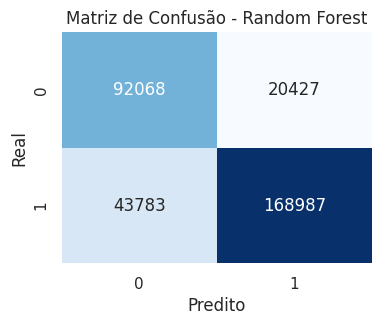


XGBoost
Acurácia: 0.8067 | Precisão: 0.8937 | Recall: 0.7996 | F1: 0.8440


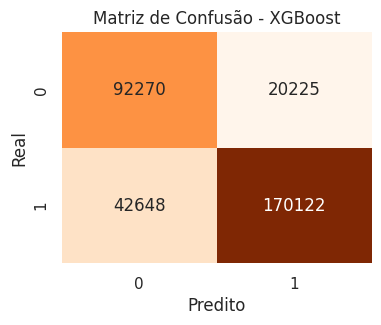


LightGBM
Acurácia: 0.8046 | Precisão: 0.8905 | Recall: 0.7996 | F1: 0.8426


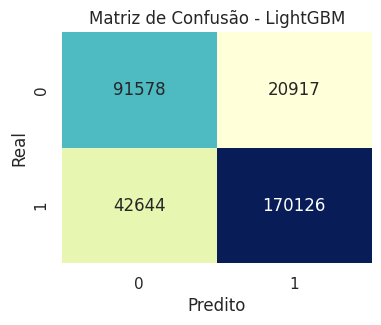


Naive Bayes (Otimizado)
Acurácia: 0.7000 | Precisão: 0.8552 | Recall: 0.6518 | F1: 0.7398


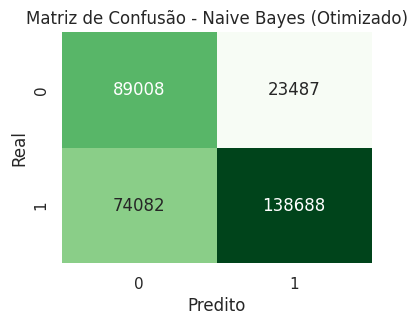


GNN Profunda
Acurácia: 0.7414 | Precisão: 0.9074 | Recall: 0.6734 | F1: 0.7731


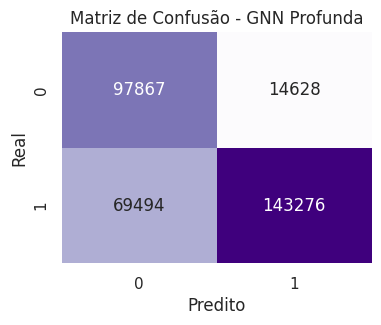

In [ ]:
# ==============================================================================
# CÉLULA 6: AVALIAÇÃO FINAL
# ==============================================================================
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

def avaliar_modelo_final(y_true, y_pred, nome_modelo, cmap='Blues'):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{'='*40}\n{nome_modelo}\n{'='*40}")
    print(f"Acurácia: {acc:.4f} | Precisão: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False)
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()
    return [acc, prec, rec, f1]

metrics_rf = avaliar_modelo_final(y_test, rf_model.predict(X_test), "Random Forest", 'Blues')
metrics_xgb = avaliar_modelo_final(y_test, xgb_model.predict(X_test), "XGBoost", 'Oranges')
metrics_lgbm = avaliar_modelo_final(y_test, lgbm_model.predict(X_test), "LightGBM", 'YlGnBu')
metrics_nb_final = avaliar_modelo_final(y_test, y_pred_nb_opt, "Naive Bayes", 'Greens')
metrics_gnn_final = avaliar_modelo_final(y_test, gnn_preds_opt, "GCN", 'Purples')

### **CÉLULA 7: COMPARAÇÃO FINAL DOS MODELOS**

Nesta célula, consolidamos as métricas de avaliação de ambos os modelos (Random Forest e Naive Bayes) em um DataFrame para facilitar a comparação. Em seguida, visualizamos essas métricas usando um gráfico de barras comparativo.

Essa comparação visual é muito útil para entender rapidamente qual modelo se sai melhor em cada métrica e tomar uma decisão informada sobre qual modelo é mais adequado para a tarefa em questão, considerando os objetivos do negócio (por exemplo, se é mais importante minimizar falsos positivos ou falsos negativos).

Tabela Comparativa Final (Considerando Extração de Características):


Métrica,Acurácia,Precision,Recall,F1-Score
XGBoost (Optimized),0.806702,0.893747,0.799558,0.844033
LightGBM,0.804587,0.890512,0.799577,0.842598
Random Forest,0.802592,0.892157,0.794224,0.840347
GNN (Deep),0.741374,0.795790,0.741374,0.747585
Naive Bayes (Opt),0.700032,0.748162,0.700032,0.707329


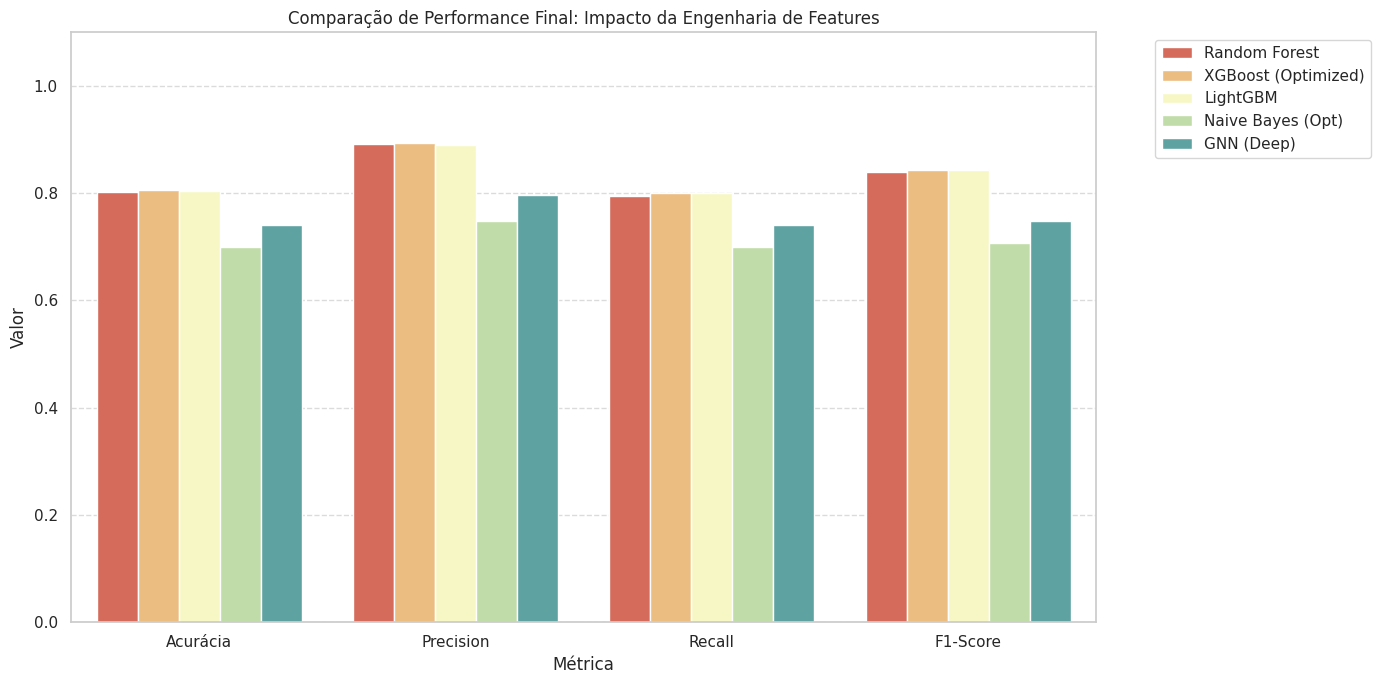

In [ ]:
# ==============================================================================
# CÉLULA 7: COMPARAÇÃO FINAL ATUALIZADA
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_compare = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': metrics_rf,
    'XGBoost (Optimized)': metrics_xgb,
    'LightGBM': metrics_lgbm,
    'Naive Bayes (Opt)': metrics_nb_opt,
    'GNN (Deep)': metrics_gnn_opt
})

print("Tabela Comparativa Final (Considerando Extração de Características):")
display(df_compare.set_index('Métrica').T.sort_values(by='Acurácia', ascending=False))

df_compare_melted = df_compare.melt(id_vars='Métrica', var_name='Modelo', value_name='Valor')
plt.figure(figsize=(14, 7))
sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=df_compare_melted, palette='Spectral')
plt.title('Comparação de Performance Final: Impacto da Engenharia de Features')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Comparação de Modelos com Curva ROC (Classificação Binária)

Esta célula avalia e compara o desempenho dos modelos **Random Forest** e **Naive Bayes** utilizando a **Curva ROC** e a métrica **AUC (Area Under the Curve)**. Primeiro, o método `predict_proba()` é usado para obter as probabilidades da **classe positiva (coluna 1)**, pois a curva ROC trabalha com probabilidades e não com rótulos discretos. Em seguida, a função `roc_curve()` calcula a **Taxa de Falsos Positivos (FPR)** e a **Taxa de Verdadeiros Positivos (TPR)** para diferentes limiares de decisão, permitindo construir a curva. A função `roc_auc_score()` mede a **área sob a curva (AUC)**, que resume o desempenho do modelo em um único valor: quanto mais próximo de 1, melhor a capacidade de separar as classes; valores próximos de 0.5 indicam desempenho aleatório. O gráfico final plota as curvas ROC de ambos os modelos, além de uma linha diagonal representando o classificador aleatório como referência. Dessa forma, é possível comparar visualmente e numericamente qual modelo apresenta melhor poder de discriminação, sendo o modelo com **maior AUC e curva mais próxima do canto superior esquerdo** o mais eficiente.


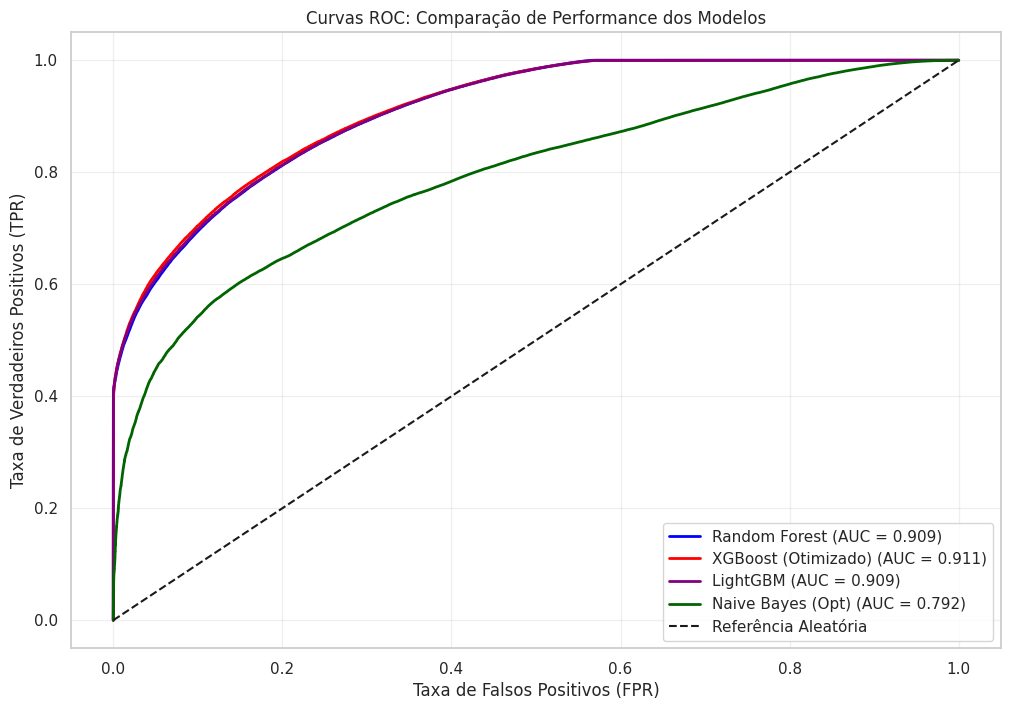

In [ ]:
# ==============================================================================
# CURVA ROC: COMPARAÇÃO DOS MELHORES MODELOS
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(12, 8))

modelos_plot = [
    (rf_model, 'Random Forest', 'blue', X_test),
    (xgb_model, 'XGBoost (Otimizado)', 'red', X_test),
    (lgbm_model, 'LightGBM', 'purple', X_test),
    (nb_model_opt, 'Naive Bayes (Opt)', 'darkgreen', X_test_pt)
]

for mod, nome, cor, data_test in modelos_plot:
    probs = mod.predict_proba(data_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})', color=cor, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Referência Aleatória')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC: Comparação de Performance dos Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()